<a href="https://colab.research.google.com/github/michael-zhang0/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sihan Michael Zhang

**Date:** 9/6/2026

In [43]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd

# Q1.1
df = pd.read_csv('./data/airbnb_hw.csv')

# I cleaned the price variable by removing the comma from numbers
# over 999 and turning them all into float64 values
df['Price'] = df['Price'].str.replace(",", "", regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Print missing values
# No missing values after cleaning
print(df['Price'].isna().sum())

# Q1.2
df2 = pd.read_csv('./data/mn_police_use_of_force.csv')
# Create new column with imputed values to clean
# Clean subject_injury_imputed by replacing 'NaN' with 'No'
# I chose this because I think any yes's should have been explicitly
# documented already, and if they didn't document any, then the subject
# probably didn't have any visible injuries, or they would have complained
# about any injuries they received
df2['subject_injury_imputed'] = df2['subject_injury'].fillna('No')

# Find missing proportion of injuries
# 76.19%, this is a concern as that is a vast majority of the values
print(df2['subject_injury'].isna().mean())

# Cross-tabulate subject_injury with force_type
# There is a pattern when data is missing, all the 'less lethal' and 'maximal
# restraint technique' are missing
print(pd.crosstab(df2['subject_injury'].fillna('Missing'), df2['force_type']))



0
0.7619342359767892
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing             2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing                        27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
Missing                              0                          170   
No                                   1                            0   
Yes          

Year
2015.0    143
2017.0    141
2016.0    133
2011.0    128
2014.0    126
         ... 
1977.0     26
1946.0     26
1979.0     25
1940.0     24
1945.0     16
Name: count, Length: 87, dtype: int64
0.8301787592008412
0.9101934738665897


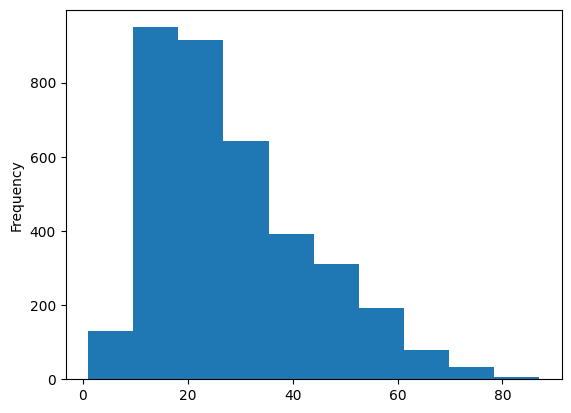

In [51]:
import pandas as pd

# Q2.1
# Read with pd.read_excel()
df = pd.read_excel('./data/GSAF5.xls')

# Q2.2
# Drop columns with data full of NaN
df = df.drop(columns=['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
                       'original order', 'Unnamed: 21', 'Unnamed: 22'])

# Q2.3
# Remove NaN values, keep years >= 1940, show how many attacks for each year
# Years looks like it contains certain years from 1500 to about 1850, then most
# years after 1850. It also contains 0, 5, 77, and 1000. It also had a nan in
# there. Attacks are increasing over time, with ~20-30 in the early to mid 1900s
# and >120 in the 2010s.
df = df.dropna(subset=['Year'])
df = df[df['Year'] >= 1940]
print(df['Year'].value_counts())

# Q2.4
# Remove NaN values, force all to be numeric, plot histogram of ages
df = df.dropna(subset=['Age'])
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].plot(kind='hist')

# Q2.5
# 83.02% males
print((df['Sex'] == 'M').mean())

# Q2.6
# 91.02% unprovoked
df = df[df['Type'].isin(['Provoked', 'Unprovoked', 'Unknown'])]
print((df['Type'] == 'Unprovoked').mean())

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


data  notebook.ipynb  README.md  tidy_data.pdf


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]